# 0 - IMPORTS

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import inflection

## 0.1 Helper Functions

In [59]:
def vscode_settings():
    plt.style.use('bmh')
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 16
    
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option('display.expand_frame_repr', False)
    
    sns.set_palette("Set2")  # "Set2", "deep", "colorblind"

vscode_settings()

## 0.2 Load Data

In [9]:
df_raw = pd.read_csv('../data/train.csv')

In [10]:
df_raw.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


# 1 - DATA DESCRIPTION

In [11]:
df1 = df_raw.copy()

## 1.1 Rename/Adjust columns

In [21]:
cols_old = df1.columns

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase, cols_old))

df1.columns = cols_new
df1.columns

Index(['id', 'gender', 'age', 'driving_license', 'region_code',
       'previously_insured', 'vehicle_age', 'vehicle_damage', 'annual_premium',
       'policy_sales_channel', 'vintage', 'response'],
      dtype='object')

## 1.2 Data Dimensions

In [19]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Cols: {}'.format(df1.shape[1]))

Number of Rows: 381109
Number of Cols: 12


## 1.3 Data Types

In [24]:
df1.dtypes

id                        int64
gender                   object
age                       int64
driving_license           int64
region_code             float64
previously_insured        int64
vehicle_age              object
vehicle_damage           object
annual_premium          float64
policy_sales_channel    float64
vintage                   int64
response                  int64
dtype: object

## 1.4 Confirm NA

In [25]:
df1.isna().sum()

id                      0
gender                  0
age                     0
driving_license         0
region_code             0
previously_insured      0
vehicle_age             0
vehicle_damage          0
annual_premium          0
policy_sales_channel    0
vintage                 0
response                0
dtype: int64

## 1.5 Descriptive Statistical

In [27]:
num_attributes = df1.select_dtypes( include=['int64', 'float64'])
cat_attributes = df1.select_dtypes( exclude=['int64', 'float64'])

In [29]:
num_attributes.head()

,id,age,driving_license,region_code,previously_insured,annual_premium,policy_sales_channel,vintage,response
0,1,44,1,28.0,0,40454.0,26.0,217,1
1,2,76,1,3.0,0,33536.0,26.0,183,0
2,3,47,1,28.0,0,38294.0,26.0,27,1
3,4,21,1,11.0,1,28619.0,152.0,203,0
4,5,29,1,41.0,1,27496.0,152.0,39,0


In [30]:
cat_attributes.head()

,gender,vehicle_age,vehicle_damage
0,Male,> 2 Years,Yes
1,Male,1-2 Year,No
2,Male,> 2 Years,Yes
3,Male,< 1 Year,No
4,Female,< 1 Year,No


### 1.5.1 Numerical attributes

In [31]:
# Central Tendency - mean, median
ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew, kurtosis
d1 = pd.DataFrame(num_attributes.apply(np.std)).T
d2 = pd.DataFrame(num_attributes.apply(min)).T
d3 = pd.DataFrame(num_attributes.apply(max)).T
d4 = pd.DataFrame(num_attributes.apply( lambda x: x.max() - x.min())).T
d5 = pd.DataFrame(num_attributes.apply( lambda x: x.skew())).T
d6 = pd.DataFrame(num_attributes.apply( lambda x: x.kurtosis())).T

# concatenate

m = pd.concat([d2,d3,d4,ct1,ct2,d1,d5,d6]).T.reset_index()
m.columns = ['attributes','min','max','range','mean','median','std','skew','kurtosis']

m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,id,1.0,381109.0,381108.0,190555.000000,190555.0,110016.691870,9.443274e-16,-1.200000
1,age,20.0,85.0,65.0,38.822584,36.0,15.511591,6.725390e-01,-0.565655
2,driving_license,0.0,1.0,1.0,0.997869,1.0,0.046109,-2.159518e+01,464.354302
3,region_code,0.0,52.0,52.0,26.388807,28.0,13.229871,-1.152664e-01,-0.867857
4,previously_insured,0.0,1.0,1.0,0.458210,0.0,0.498251,1.677471e-01,-1.971871
5,annual_premium,2630.0,540165.0,537535.0,30564.389581,31669.0,17213.132474,1.766087e+00,34.004569
6,policy_sales_channel,1.0,163.0,162.0,112.034295,133.0,54.203924,-9.000081e-01,-0.970810
7,vintage,10.0,299.0,289.0,154.347397,154.0,83.671194,3.029517e-03,-1.200688
8,response,0.0,1.0,1.0,0.122563,0.0,0.327935,2.301906e+00,3.298788


### 1.5.2 Categorical attributes

In [33]:
cat_attributes.apply( lambda x: x.unique().shape[0])

gender            2
vehicle_age       3
vehicle_damage    2
dtype: int64

In [34]:
df2 = df1.copy()

In [35]:
df2.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [36]:
# vehicle_age
df2['vehicle_age'] = df2['vehicle_age'].map({
    '< 1 Year': 'before_1_year',
    '1-2 Year': 'between_1_2_years',
    '> 2 Years': 'over_2_years'
})

In [38]:
df3 = df2.copy()

In [40]:
df4 = df3.copy()

In [41]:
df4.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,1,Male,44,1,28.0,0,over_2_years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,between_1_2_years,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,over_2_years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,before_1_year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,before_1_year,No,27496.0,152.0,39,0


## 4.1 Hypoteses

**1 -** Pessoas mais velhas tendem a comprar maiores seguros.

**2 -** Pessoas sem driver license nao adquirem seguros de carros.

**3 -** Pessoas que já tiveram acidentes de carro procuram por seguros.

**4 -** Pessoas que possuem seguro de saúde a mais tempo, procuram por seguros de carros.

## 4.2 Univariate Analysis

### 4.2.1 Numerical Variable

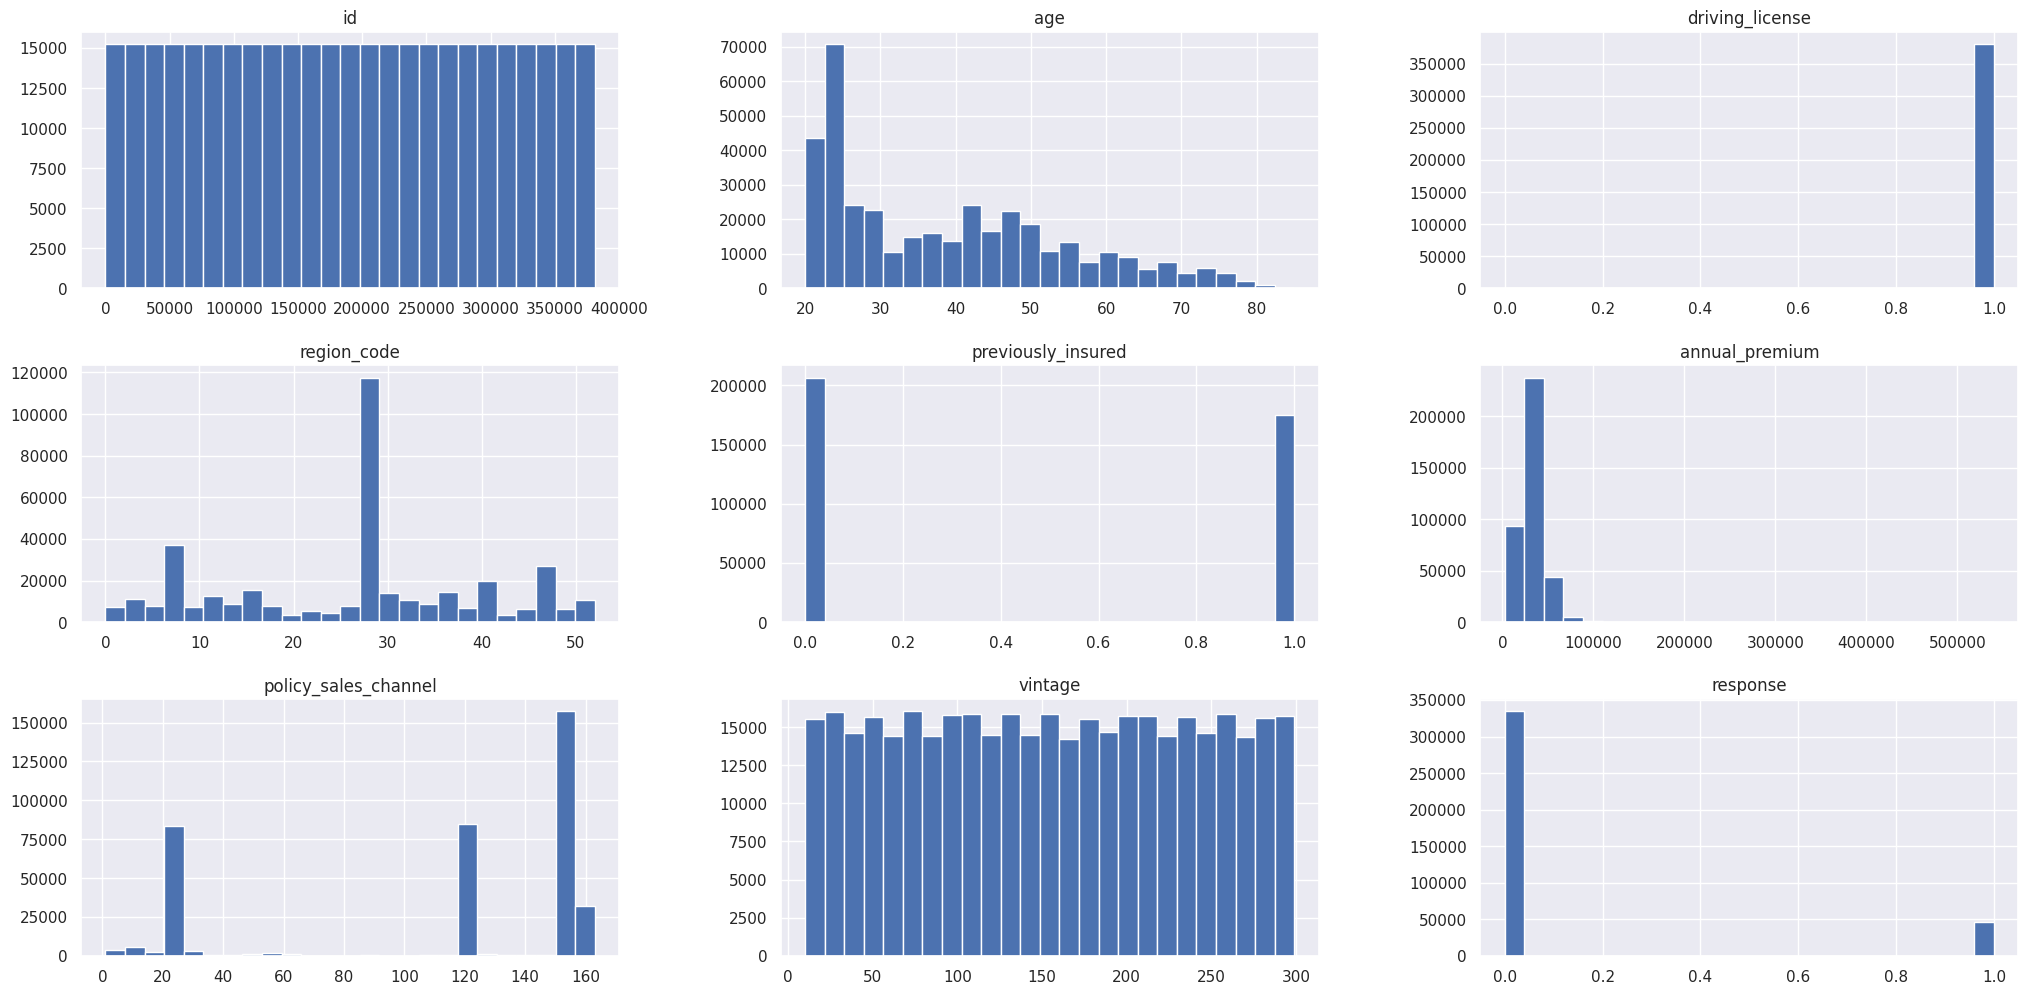

In [44]:
num_attributes.hist( bins=25);

### 4.2.2 Categorical Variable

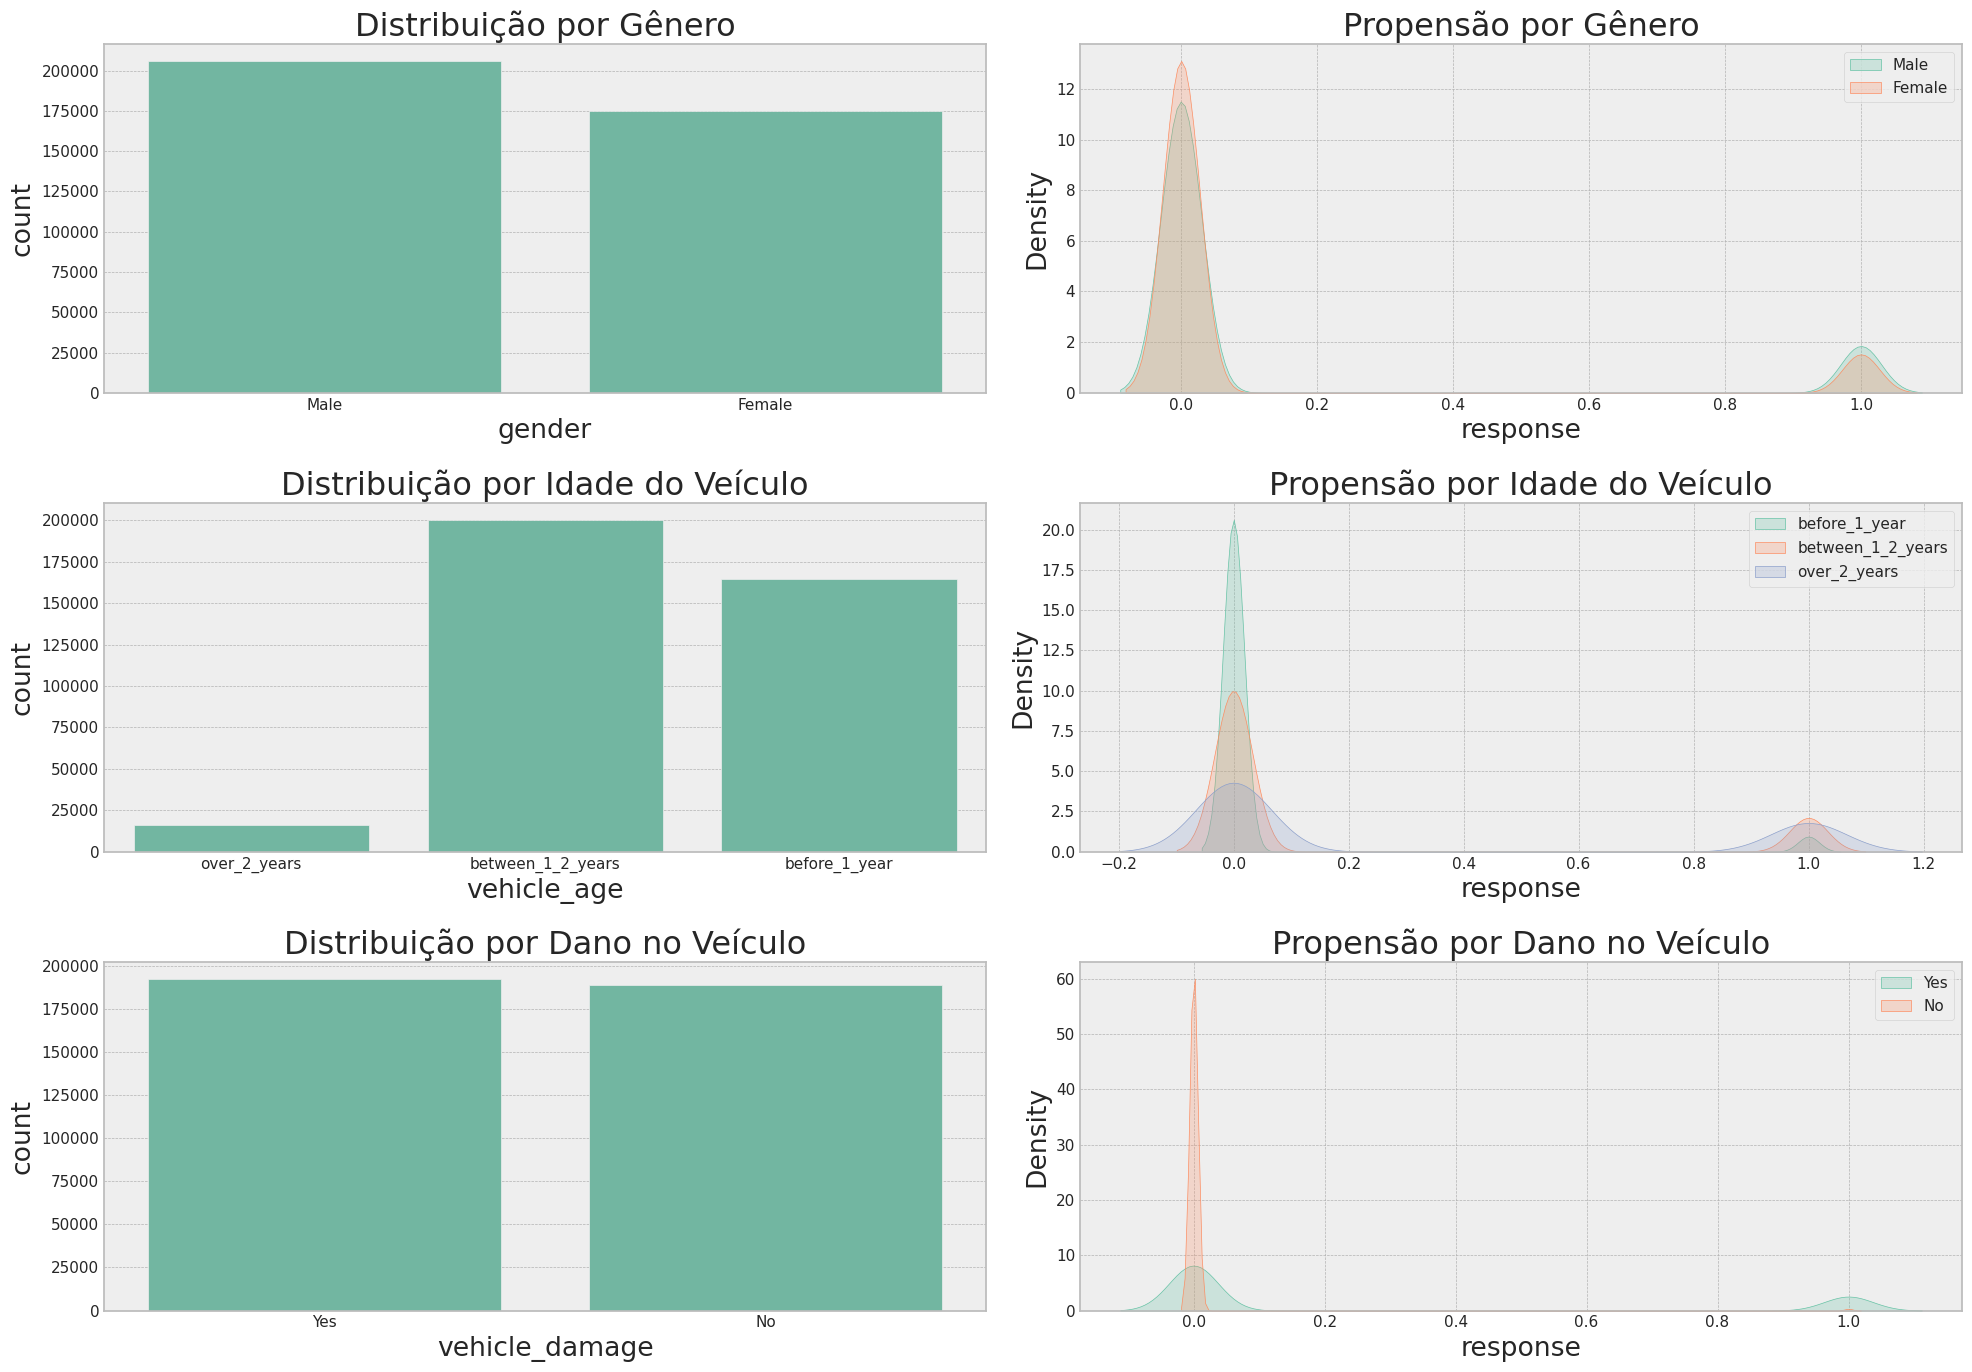

In [65]:
fig, axes = plt.subplots(3, 2, figsize=(20, 14))

# gender - countplot
sns.countplot(x='gender', data=df4, ax=axes[0,0])
axes[0,0].set_title('Distribuição por Gênero')

# gender - KDE
sns.kdeplot(df4[df4['gender'] == 'Male']['response'], label='Male', fill=True, ax=axes[0,1])
sns.kdeplot(df4[df4['gender'] == 'Female']['response'], label='Female', fill=True, ax=axes[0,1])
axes[0,1].set_title('Propensão por Gênero')
axes[0,1].legend()

# vehicle_age - countplot
sns.countplot(x='vehicle_age', data=df4, ax=axes[1,0])
axes[1,0].set_title('Distribuição por Idade do Veículo')

# vehicle_age - KDE
sns.kdeplot(df4[df4['vehicle_age'] == 'before_1_year']['response'], label='before_1_year', fill=True, ax=axes[1,1])
sns.kdeplot(df4[df4['vehicle_age'] == 'between_1_2_years']['response'], label='between_1_2_years', fill=True, ax=axes[1,1])
sns.kdeplot(df4[df4['vehicle_age'] == 'over_2_years']['response'], label='over_2_years', fill=True, ax=axes[1,1])
axes[1,1].set_title('Propensão por Idade do Veículo')
axes[1,1].legend()

# vehicle_damage - countplot
sns.countplot(x='vehicle_damage', data=df4, ax=axes[2,0])
axes[2,0].set_title('Distribuição por Dano no Veículo')

# vehicle_damage - KDE
sns.kdeplot(df4[df4['vehicle_damage'] == 'Yes']['response'], label='Yes', fill=True, ax=axes[2,1])
sns.kdeplot(df4[df4['vehicle_damage'] == 'No']['response'], label='No', fill=True, ax=axes[2,1])
axes[2,1].set_title('Propensão por Dano no Veículo')
axes[2,1].legend()

plt.tight_layout()
plt.show()

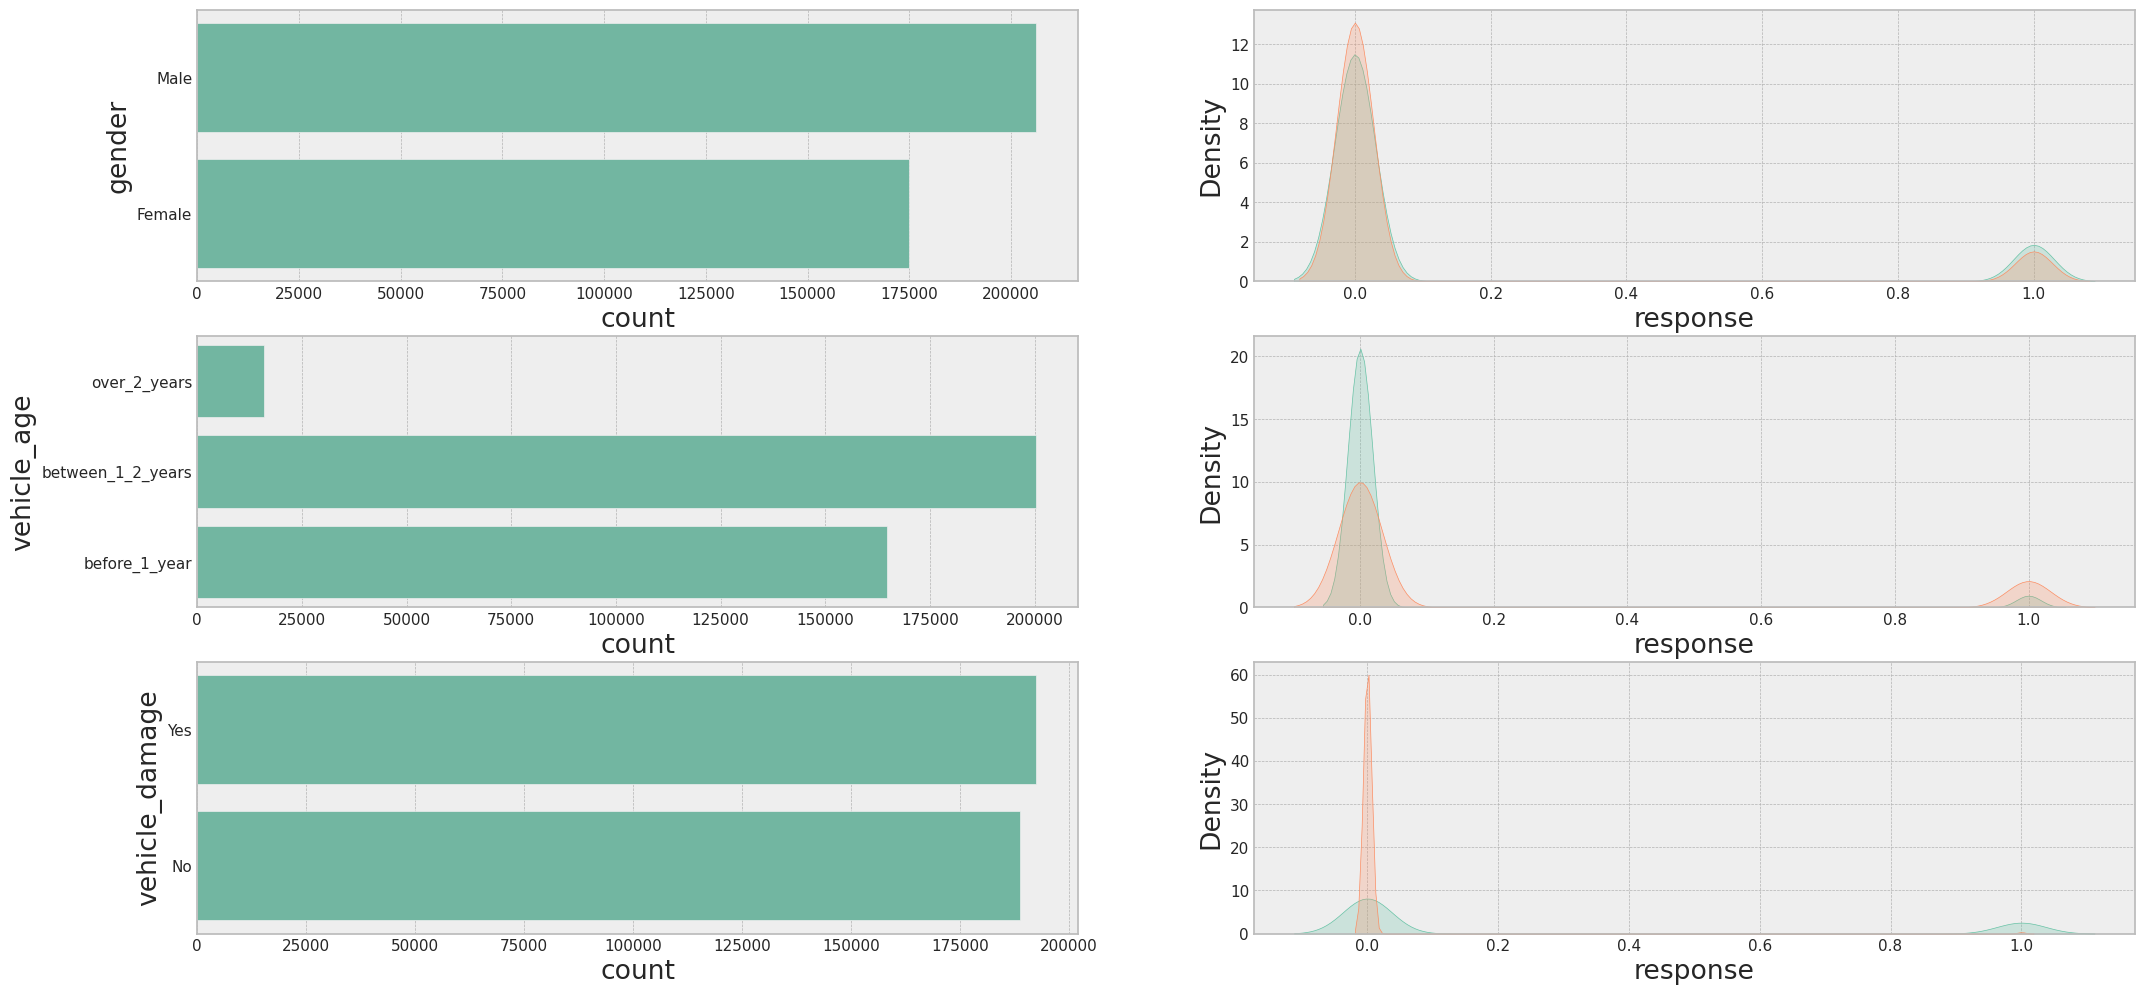

In [ ]:
# gender
plt.subplot(3, 2, 1)
sns.countplot(df4['gender'])

plt.subplot(3, 2, 2)
sns.kdeplot(df4[df4['gender'] == 'Male']['response'], label='Male', fill=True)
sns.kdeplot(df4[df4['gender'] == 'Female']['response'], label='Female', fill=True)


# vehicle_age
plt.subplot(3, 2, 3)
sns.countplot(df4['vehicle_age'])

plt.subplot(3, 2, 4)
sns.kdeplot(df4[df4['vehicle_age'] == 'before_1_year']['response'], label='before_1_year', fill=True)
sns.kdeplot(df4[df4['vehicle_age'] == 'between_1_2_years']['response'], label='between_1_2_years', fill=True)
sns.kdeplot(df4[df4['vehicle_age'] == 'over_2_years	']['response'], label='over_2_years', fill=True)

# vehicle_damage
plt.subplot(3, 2, 5)
sns.countplot(df4['vehicle_damage'])

plt.subplot(3, 2, 6)
sns.kdeplot(df4[df4['vehicle_damage'] == 'Yes']['response'], label='Yes', fill=True)
sns.kdeplot(df4[df4['vehicle_damage'] == 'No']['response'], label='No', fill=True);